Saving archive.zip to archive (3).zip
   study_hours  attendance  sleep_hours  internet_usage  \
0            7          56            8               7   
1            4          69            5               3   
2           11          60            7               6   
3            8          99            9               8   
4            5          52            8               6   

   assignments_completed  previous_score  exam_score placement_status  
0                     10              62      100.00           Placed  
1                      8              56      100.00           Placed  
2                     10              45      100.00           Placed  
3                      4              55       90.17           Placed  
4                      8              40       78.82           Placed  

Model Performance
R2 Score: 0.6634458623051924
Mean Absolute Error: 6.917285717910665

Prediction Result
   Actual Score  Predicted Score
0        100.00       104.483636
1  

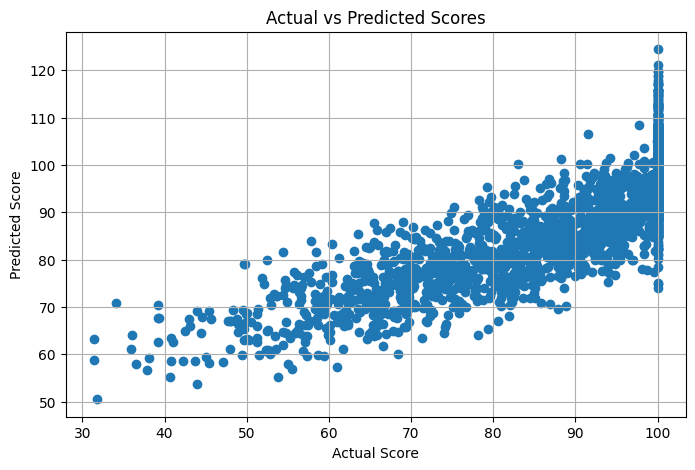


===== Personalized Study Planner =====

Predicted Score: 104.48
Excellent! Continue your current study routine and solve advanced questions.

Predicted Score: 86.34
Good! Revise daily and practice mock tests.

Predicted Score: 88.74
Good! Revise daily and practice mock tests.

Predicted Score: 76.23
Good! Revise daily and practice mock tests.

Predicted Score: 91.13
Excellent! Continue your current study routine and solve advanced questions.


In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Upload dataset manually
from google.colab import files
uploaded = files.upload()

# Read uploaded CSV
df = pd.read_csv(next(iter(uploaded)))

# Show first 5 rows
print(df.head())

# Features
X = df[['study_hours',
        'attendance',
        'sleep_hours',
        'internet_usage',
        'assignments_completed',
        'previous_score']]

# Target
y = df['exam_score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("\nModel Performance")
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# Result Table
result = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

print("\nPrediction Result")
print(result.head(10))

# Graph
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.grid(True)
plt.show()

# AI Study Planner
print("\n===== Personalized Study Planner =====")

for score in y_pred[:5]:
    print(f"\nPredicted Score: {round(score,2)}")

    if score >= 90:
        print("Excellent! Continue your current study routine and solve advanced questions.")
    elif score >= 75:
        print("Good! Revise daily and practice mock tests.")
    elif score >= 50:
        print("Needs Improvement. Study 2-3 hours daily and complete assignments.")
    else:
        print("Work Hard! Revise basics, follow a timetable, and ask teachers for guidance.")